# Prerequisites
You might need to bootstrap the virtual environment from the console panel:
```bash
source .venv/bin/activate  # Activate if not already
```

# Find the Spines

Install required packages

In [13]:
pip install inference-sdk matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


Imports

In [3]:
from inference_sdk import InferenceHTTPClient
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Client

In [4]:
import os

# Load API key from environment variable
api_key = os.getenv('ROBOFLOW_PRIVATE_API_KEY')

if api_key is None:
    print("Warning: ROBOFLOW_PRIVATE_API_KEY not found in environment variables")
else:
    print("API key loaded successfully!")

# Fix certificate issue
import certifi
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

# Initialize the Roboflow client
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key=api_key
)

API key loaded successfully!


Inference

In [5]:
# Run the model on your image
# Note: You may need to find the exact model_id for the finetune-mrcnn model
# Format is usually "workspace/project/version"
result = CLIENT.infer("IMG_4014.jpeg", model_id="finetune-mrcnn/2")
print(result)

{'inference_id': 'a14c92a2-3a1b-4cbe-9a4f-e65ff56ed5e3', 'time': 0.8614558920089621, 'image': {'width': 4032, 'height': 3024}, 'predictions': [{'x': 958.5, 'y': 1721.5, 'width': 387.0, 'height': 1549.0, 'confidence': 0.934273898601532, 'class': 'book', 'class_id': 0, 'detection_id': '95c915d4-0997-4d66-b3bb-3c037762e62b', 'points': [{'x': 781.2000122070312, 'y': 949.7249755859375}, {'x': 781.2000122070312, 'y': 1209.5999755859375}, {'x': 787.5, 'y': 1214.324951171875}, {'x': 787.5, 'y': 1233.2249755859375}, {'x': 793.800048828125, 'y': 1237.949951171875}, {'x': 793.800048828125, 'y': 1242.6749267578125}, {'x': 800.1000366210938, 'y': 1247.4000244140625}, {'x': 800.1000366210938, 'y': 1266.2999267578125}, {'x': 806.4000244140625, 'y': 1271.0250244140625}, {'x': 806.4000244140625, 'y': 1393.875}, {'x': 812.7000122070312, 'y': 1398.5999755859375}, {'x': 812.7000122070312, 'y': 1422.2249755859375}, {'x': 819.0, 'y': 1426.949951171875}, {'x': 819.0, 'y': 1436.4000244140625}, {'x': 825.30004

Results

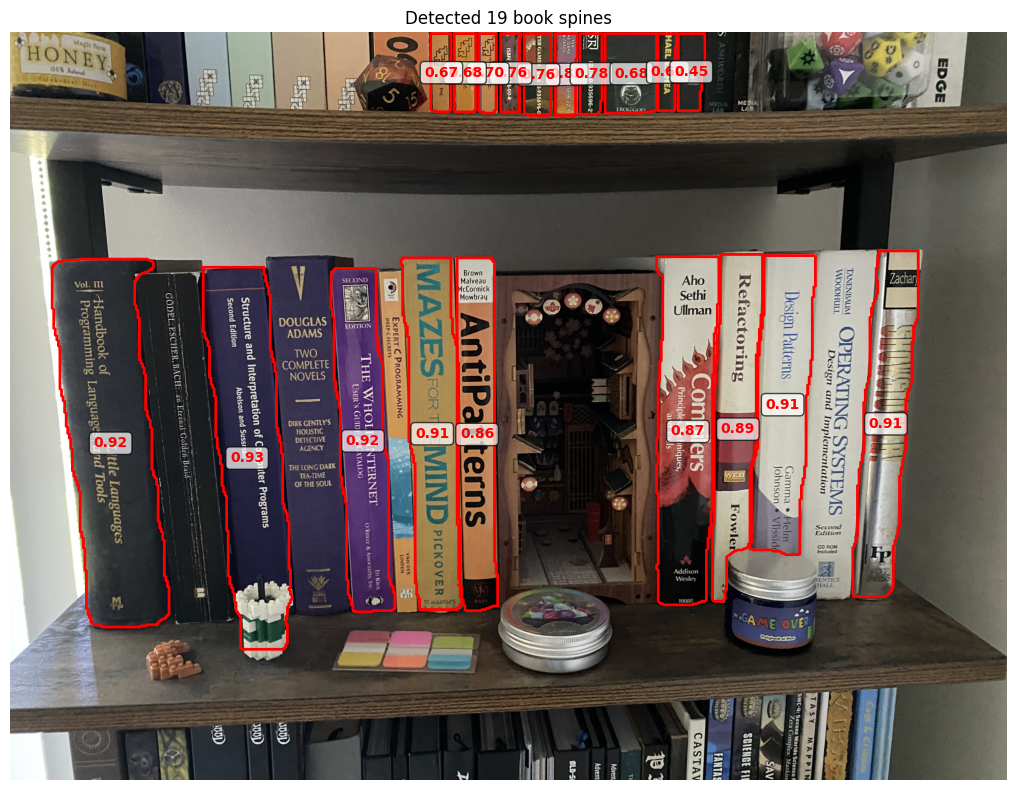


Found 19 book spines!
Book 1: confidence 93.43%
Book 2: confidence 92.47%
Book 3: confidence 92.44%
Book 4: confidence 90.83%
Book 5: confidence 90.77%
Book 6: confidence 90.62%
Book 7: confidence 88.69%
Book 8: confidence 87.48%
Book 9: confidence 86.22%
Book 10: confidence 81.90%
Book 11: confidence 77.84%
Book 12: confidence 76.07%
Book 13: confidence 75.86%
Book 14: confidence 70.38%
Book 15: confidence 68.10%
Book 16: confidence 67.59%
Book 17: confidence 66.59%
Book 18: confidence 61.82%
Book 19: confidence 44.78%


In [17]:
# Load the image
img = Image.open("IMG_4014.jpeg")

# Create figure and axes
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(img)

# Draw shapes for each detected book spine
for prediction in result['predictions']:
    x = prediction['x']
    y = prediction['y']
    width = prediction['width']
    height = prediction['height']
    confidence = prediction['confidence']
    points = prediction['points']
    
    # Extract points as list of (x, y) tuples
    points_list = [(p['x'], p['y']) for p in points]
    
    # Create polygon patch
    poly = patches.Polygon(
        points_list,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(poly)
    
    # Add confidence label at the center of the bounding box
    ax.text(x, y, f'{confidence:.2f}', 
            color='red', fontsize=10, weight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
            ha='center', va='center')

plt.axis('off')
plt.title(f'Detected {len(result["predictions"])} book spines')
plt.tight_layout()
plt.show()

# Print summary
print(f"\nFound {len(result['predictions'])} book spines!")
for i, pred in enumerate(result['predictions'], 1):
    print(f"Book {i}: confidence {pred['confidence']:.2%}")

# Identify the Books

More packages

In [6]:
pip install paddlepaddle paddleocr requests

Note: you may need to restart the kernel to use updated packages.


More libraries

In [7]:
from paddleocr import PaddleOCR
import requests
from io import BytesIO
import re
import random

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


Crop the book spine from the image

In [8]:
def crop_spine(image_path, prediction):
    """Crop a book spine from the image using polygon points"""
    img = Image.open(image_path)
    
    # Get points from prediction
    points = prediction['points']
    
    # Calculate bounding box from points
    x_coords = [p['x'] for p in points]
    y_coords = [p['y'] for p in points]
    
    left = min(x_coords)
    top = min(y_coords)
    right = max(x_coords)
    bottom = max(y_coords)
    
    # Crop and return
    cropped = img.crop((left, top, right, bottom))
    return cropped

Identify the book

In [12]:
# Initialize PaddleOCR (only needs to be done once)
ocr = PaddleOCR(use_angle_cls=True, lang='en')

def extract_text_from_spine(cropped_image):
    """Use PaddleOCR to extract text from book spine"""
    # Save to temp file (PaddleOCR needs a file path)
    temp_path = "temp_spine.jpg"
    cropped_image.save(temp_path)
    
    # Run OCR
    result = ocr.predict(temp_path)
    
    # Extract all text
    if result and result[0]:
        text_lines = [line[1][0] for line in result[0]]
        full_text = " ".join(text_lines)
        return full_text
    return ""

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ted/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ted/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ted/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ted/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ted/.paddlex/official_models/en_P

Get extra book metadata

In [10]:
def identify_book_from_text(text):
    """Search Google Books with extracted text"""
    if not text.strip():
        return {"title": "Could not read text", "author": "Unknown", "confidence": "low"}
    
    print(f"  Extracted text: {text}")
    
    # Clean the text
    clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', text).strip()
    # Limit to first 10 words to improve search relevance
    clean_text = ' '.join(clean_text.split()[:10])
    print(f"  Cleaned text: {clean_text}")
    
    # Search Google Books
    url = "https://www.googleapis.com/books/v1/volumes"
    params = {"q": clean_text, "maxResults": 3}
    
    try:
        response = requests.get(url, params=params)
        print(f"  API Status: {response.status_code}")
        if response.status_code == 200:
            data = response.json()
            total_items = data.get('totalItems', 0)
            print(f"  Total items found: {total_items}")
            if total_items > 0:
                book = data['items'][0]['volumeInfo']
                confidence = "high" if total_items > 2 else "medium"
                return {
                    "title": book.get('title', 'Unknown'),
                    "author": ", ".join(book.get('authors', ['Unknown'])),
                    "confidence": confidence,
                    "published": book.get('publishedDate'),
                    "isbn": next((id['identifier'] for id in book.get('industryIdentifiers', []) 
                                if id['type'] in ['ISBN_13', 'ISBN_10']), None)
                }
    except Exception as e:
        print(f"  Search error: {e}")
    
    return {"title": f"No match found for: {clean_text}", "author": "Unknown", "confidence": "low"}

Process the predictions


--- Processing Book 1 ---


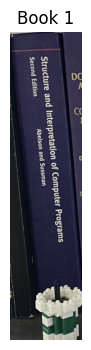

  Extracted text: n a o t o e e e e e e e i e e
  Cleaned text: n a o t o e e e e e
  API Status: 200
  Total items found: 0
Title: No match found for: n a o t o e e e e e
Author: Unknown
Confidence: low

--- Processing Book 2 ---


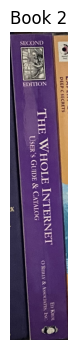

  Extracted text: n a o t o e e e e e e e i e e
  Cleaned text: n a o t o e e e e e
  API Status: 200
  Total items found: 0
Title: No match found for: n a o t o e e e e e
Author: Unknown
Confidence: low

--- Processing Book 3 ---


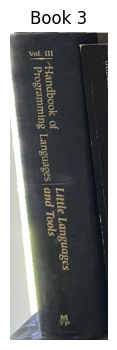

  Extracted text: n a o t o e e e e e e e i e e
  Cleaned text: n a o t o e e e e e
  API Status: 200
  Total items found: 0
Title: No match found for: n a o t o e e e e e
Author: Unknown
Confidence: low


In [13]:
# Process each detected book spine
identified_books = []

# Sort predictions by confidence descending and take top 3
top_predictions = sorted(result['predictions'], key=lambda x: x['confidence'], reverse=True)[:3]

for i, prediction in enumerate(top_predictions, 1):
    print(f"\n--- Processing Book {i} ---")
    
    # Crop the spine
    spine_img = crop_spine("IMG_4014.jpeg", prediction)
    
    # Display the cropped spine
    plt.figure(figsize=(3, 4))
    plt.imshow(spine_img)
    plt.title(f"Book {i}")
    plt.axis('off')
    plt.show()
    
    # Extract text and identify book
    try:
        text = extract_text_from_spine(spine_img)
        book_info = identify_book_from_text(text)
        
        print(f"Title: {book_info['title']}")
        print(f"Author: {book_info['author']}")
        print(f"Confidence: {book_info['confidence']}")
        if book_info.get('isbn'):
            print(f"ISBN: {book_info['isbn']}")
        
        identified_books.append({
            'spine_num': i,
            'detection_confidence': prediction['confidence'],
            'extracted_text': text,
            **book_info
        })
        
    except Exception as e:
        print(f"Error: {e}")
        identified_books.append({
            'spine_num': i,
            'error': str(e)
        })

Report on results

In [40]:
# Print nice summary
print("\n" + "="*50)
print(f"IDENTIFIED {len([b for b in identified_books if 'title' in b])} BOOKS")
print("="*50)

for book in identified_books:
    if 'title' in book:
        print(f"\n�책 {book['title']}")
        print(f"   by {book['author']}")
        print(f"   Confidence: {book['confidence']}")


IDENTIFIED 19 BOOKS

�책 No match found for: n a o t o e e e e e
   by Unknown
   Confidence: low

�책 No match found for: n a o t o e e e e e
   by Unknown
   Confidence: low

�책 No match found for: n a o t o e e e e e
   by Unknown
   Confidence: low

�책 No match found for: n a o t o e e e e e
   by Unknown
   Confidence: low

�책 No match found for: n a o t o e e e e e
   by Unknown
   Confidence: low

�책 No match found for: n a o t o e e e e e
   by Unknown
   Confidence: low

�책 No match found for: n a o t o e e e e e
   by Unknown
   Confidence: low

�책 No match found for: n a o t o e e e e e
   by Unknown
   Confidence: low

�책 No match found for: n a o t o e e e e e
   by Unknown
   Confidence: low

�책 No match found for: n a o t o e e e e e
   by Unknown
   Confidence: low

�책 No match found for: n a o t o e e e e e
   by Unknown
   Confidence: low

�책 No match found for: n a o t o e e e e e
   by Unknown
   Confidence: low

�책 No match found for: n a o t o e e e e e
   by Unkno